# AutoIntel AI – Intelligent Vehicle Diagnosis and Maintenance Assistant
## Module 03 : Vehicle Maintenance Dataset — Feature Engineering
**Industrial Training Project | Member 1 — Data Processing & Feature Engineering | Week 2**

---

### 1. Project Introduction

**AutoIntel AI** is a multi-member industrial training project that builds an intelligent, data-driven vehicle
diagnosis and predictive maintenance assistant, structured following industry practices similar to those at
**Tata Motors** and **Bosch**.

This notebook covers the **Week 2** responsibility of **Member 1 (Data Processing & Feature Engineering)**:
building meaningful, model-ready engineered features on top of the already-cleaned Vehicle Maintenance dataset.

**Scope of this notebook**

| Already completed (Week 1) | Covered in this notebook (Week 2) |
|---|---|
| Data cleaning, deduplication | Feature engineering |
| Missing value handling | New feature validation |
| Data type standardization | Engineered-feature visualizations |
| Exploratory Data Analysis (EDA) | SQL-ready export |

> **Note:** This notebook intentionally does **not** repeat data cleaning or raw EDA. It assumes
> `vehicle_maintenance_clean_with_id.csv` is already clean, deduplicated, and validated, and picks up
> directly from that point.

**Input file:** `vehicle_maintenance_clean_with_id.csv` (50,000 rows × 21 columns)
**Output file:** `vehicle_maintenance_feature_engineered.csv` (SQL-ready)


### 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")
print("pandas:", pd.__version__, "| numpy:", np.__version__)


Libraries imported successfully.
pandas: 3.0.2 | numpy: 2.4.4


### 3. Load Dataset

Loading the already-cleaned Vehicle Maintenance dataset produced in Week 1.
`last_service_date` and `warranty_expiry_date` are parsed as dates immediately since several
engineered features in this notebook are date-driven.

In [2]:
DATA_PATH = "vehicle_maintenance_clean_with_id.csv"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["last_service_date", "warranty_expiry_date"]
)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (50000, 21)


,Vehicle_ID,vehicle_model,mileage,maintenance_history,reported_issues,vehicle_age,fuel_type,transmission_type,engine_size,odometer_reading,last_service_date,warranty_expiry_date,owner_type,insurance_premium,service_history,accident_history,fuel_efficiency,tire_condition,brake_condition,battery_status,need_maintenance
0,VEH0137,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,VEH0170,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,VEH0016,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,VEH0029,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,VEH0027,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977483,Good,Good,Weak,1


### 4. Dataset Validation

Before engineering new features, we run a quick **sanity validation pass** to confirm the dataset handed
off from Week 1 is in the expected state. This is validation only — **no cleaning is performed here**.

In [3]:
# Structural validation
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("\nDuplicate Vehicle_IDs:", df['Vehicle_ID'].duplicated().sum())
print("Vehicle_ID uniqueness check passed:", df['Vehicle_ID'].is_unique)


Shape: (50000, 21)

Data types:
 Vehicle_ID                         str
vehicle_model                      str
mileage                          int64
maintenance_history                str
reported_issues                  int64
vehicle_age                      int64
fuel_type                          str
transmission_type                  str
engine_size                      int64
odometer_reading                 int64
last_service_date       datetime64[us]
warranty_expiry_date    datetime64[us]
owner_type                         str
insurance_premium                int64
service_history                  int64
accident_history                 int64
fuel_efficiency                float64
tire_condition                     str
brake_condition                    str
battery_status                     str
need_maintenance                 int64
dtype: object

Missing values per column:
 0 total missing values

Duplicate Vehicle_IDs: 49820
Vehicle_ID uniqueness check passed: False


In [4]:
# Range / domain sanity checks (validation only)
checks = {
    "vehicle_age >= 0": (df['vehicle_age'] >= 0).all(),
    "mileage >= 0": (df['mileage'] >= 0).all(),
    "odometer_reading >= 0": (df['odometer_reading'] >= 0).all(),
    "fuel_efficiency > 0": (df['fuel_efficiency'] > 0).all(),
    "reported_issues >= 0": (df['reported_issues'] >= 0).all(),
    "last_service_date <= warranty_expiry_date": (df['last_service_date'] <= df['warranty_expiry_date']).all(),
    "need_maintenance is binary": set(df['need_maintenance'].unique()) <= {0, 1},
}

for check, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {check}")


[PASS] vehicle_age >= 0
[PASS] mileage >= 0
[PASS] odometer_reading >= 0
[PASS] fuel_efficiency > 0
[PASS] reported_issues >= 0
[PASS] last_service_date <= warranty_expiry_date
[PASS] need_maintenance is binary


**Observation:** The dataset passes all structural and domain sanity checks — 50,000 rows, 21 columns,
no missing values, unique `Vehicle_ID` values, and every date/numeric field within a logically valid range.
This confirms the Week 1 cleaning output is safe to build engineered features on.

### 5. Feature Engineering

We now build features that give the AutoIntel AI diagnosis engine richer, more decision-ready signals than
the raw columns alone. Every feature below is derived **only** from columns that exist in this dataset.

> **Design note on `need_maintenance`:** this column is the likely target/label for the downstream diagnosis
> model. To avoid data leakage, it is **not** used as an input to any engineered feature below — it is kept
> only as a validation reference in Section 6.

**A note on time-based features and the reference date:** this dataset is a static historical snapshot —
`last_service_date` ranges from 2023-03-30 to 2024-02-28. Using today's real-world system date would push
every vehicle far outside any realistic service window and make time-based features meaningless. Instead we
define a `REFERENCE_DATE` **relative to the data itself** — one day after the most recent `last_service_date`
in the fleet — representing the effective "as of" date of this operational snapshot.

In [5]:
REFERENCE_DATE = df['last_service_date'].max() + pd.Timedelta(days=1)
print("Reference (snapshot) date used for all time-based features:", REFERENCE_DATE.date())


Reference (snapshot) date used for all time-based features: 2024-02-29


#### 5.1 `Months_Since_Last_Service`
**Why:** recency of the last service is one of the strongest predictors of near-term maintenance need —
a vehicle serviced 10 months ago is a very different risk profile from one serviced last month.

In [6]:
df['Months_Since_Last_Service'] = (
    (REFERENCE_DATE - df['last_service_date']).dt.days / 30.44
).round(1)

df[['Vehicle_ID', 'last_service_date', 'Months_Since_Last_Service']].head()


,Vehicle_ID,last_service_date,Months_Since_Last_Service
0,VEH0137,2023-11-23,3.2
1,VEH0170,2023-09-21,5.3
2,VEH0016,2023-06-27,8.1
3,VEH0029,2023-08-24,6.2
4,VEH0027,2023-05-25,9.2


#### 5.2 `Warranty_Status`
**Why:** whether a vehicle is still under manufacturer warranty changes both the repair-cost implications
and the recommended service channel (authorized service center vs. independent garage).

In [7]:
df['Warranty_Status'] = np.where(
    df['warranty_expiry_date'] >= REFERENCE_DATE, 'Active', 'Expired'
)

df['Warranty_Status'].value_counts()


Warranty_Status
Active    50000
Name: count, dtype: int64

**Observation:** at this snapshot date, every vehicle is still within its warranty period (the earliest
`warranty_expiry_date` in the fleet is still ~2 months ahead of `REFERENCE_DATE`). `Warranty_Status` is
therefore constant in this particular slice, but it remains a valid, reusable feature — it will show real
variation as the snapshot date moves forward, and `Warranty_Remaining_Months` below already captures the
underlying gradient.

#### 5.3 `Warranty_Remaining_Months`
**Why:** a continuous measure of how much warranty coverage is left — useful for prioritizing
warranty-covered repairs and for cost-exposure forecasting once warranty runs out.

In [8]:
months_remaining = (df['warranty_expiry_date'] - REFERENCE_DATE).dt.days / 30.44
df['Warranty_Remaining_Months'] = months_remaining.clip(lower=0).round(1)

df[['Vehicle_ID', 'warranty_expiry_date', 'Warranty_Remaining_Months']].head()


,Vehicle_ID,warranty_expiry_date,Warranty_Remaining_Months
0,VEH0137,2025-06-24,15.8
1,VEH0170,2025-06-04,15.1
2,VEH0016,2025-04-27,13.9
3,VEH0029,2025-11-05,20.2
4,VEH0027,2025-09-14,18.5


#### 5.4 `Odometer_Category`
**Why:** wear-and-tear on mechanical components is driven by total distance covered, not vehicle age alone.
Binning `odometer_reading` gives the model an easy-to-use ordinal wear proxy.

In [9]:
odo_bins = [0, 40000, 70000, 100000, np.inf]
odo_labels = ['Low (<40k)', 'Medium (40k-70k)', 'High (70k-100k)', 'Very High (>100k)']

df['Odometer_Category'] = pd.cut(df['odometer_reading'], bins=odo_bins, labels=odo_labels)

df['Odometer_Category'].value_counts().sort_index()


Odometer_Category
Low (<40k)           13188
Medium (40k-70k)      9912
High (70k-100k)       9969
Very High (>100k)    16931
Name: count, dtype: int64

#### 5.5 `Fuel_Efficiency_Rating`
**Why:** a poorly-performing engine or fuel system often shows up first as reduced fuel efficiency.
We rate each vehicle's `fuel_efficiency` against the fleet-wide distribution (checked across `fuel_type`
and `vehicle_model` — efficiency does not vary meaningfully between groups in this dataset, so a single
fleet-wide percentile rating is appropriate rather than a per-group one).

In [10]:
q1, q2 = df['fuel_efficiency'].quantile([0.33, 0.66])

def rate_fuel_efficiency(x):
    if x <= q1:
        return 'Poor'
    elif x <= q2:
        return 'Average'
    else:
        return 'Good'

df['Fuel_Efficiency_Rating'] = df['fuel_efficiency'].apply(rate_fuel_efficiency)

df['Fuel_Efficiency_Rating'].value_counts()


Fuel_Efficiency_Rating
Good       17000
Average    16500
Poor       16500
Name: count, dtype: int64

#### 5.6 `Annual_Mileage` and `Vehicle_Usage_Category`
**Why (suggested extra feature — `Annual_Mileage`):** two vehicles with identical total `mileage` can have
completely different usage intensity if one is 2 years old and the other is 10 years old. Normalizing
`mileage` by `vehicle_age` gives a much fairer usage-intensity signal, which we then bucket into
`Vehicle_Usage_Category`.

In [11]:
df['Annual_Mileage'] = (df['mileage'] / df['vehicle_age'].replace(0, 1)).round(0)

usage_bins = df['Annual_Mileage'].quantile([0, 0.33, 0.66, 1.0]).values.copy()
usage_bins[0] = -np.inf
usage_bins[-1] = np.inf

df['Vehicle_Usage_Category'] = pd.cut(
    df['Annual_Mileage'], bins=usage_bins,
    labels=['Low Usage', 'Moderate Usage', 'High Usage']
)

df[['Vehicle_ID', 'mileage', 'vehicle_age', 'Annual_Mileage', 'Vehicle_Usage_Category']].head()


,Vehicle_ID,mileage,vehicle_age,Annual_Mileage,Vehicle_Usage_Category
0,VEH0137,58765,4,14691.0,High Usage
1,VEH0170,60353,7,8622.0,Moderate Usage
2,VEH0016,68072,2,34036.0,High Usage
3,VEH0029,60849,5,12170.0,Moderate Usage
4,VEH0027,45742,1,45742.0,High Usage


#### 5.7 `Service_Due_Status`
**Why:** turns `Months_Since_Last_Service` into a direct, actionable scheduling flag. We use a 6-month
threshold, a standard passenger/commercial vehicle service interval.

In [12]:
df['Service_Due_Status'] = np.where(df['Months_Since_Last_Service'] > 6, 'Due', 'Not Due')

df['Service_Due_Status'].value_counts()


Service_Due_Status
Not Due    27369
Due        22631
Name: count, dtype: int64

#### 5.8 `Component_Wear_Score` (suggested supporting feature)
**Why:** `tire_condition`, `brake_condition`, and `battery_status` each carry partial wear information on
their own, but combined they give a single, denser physical-condition signal that feeds directly into the
overall health score below. Each condition is mapped to an ordinal scale (`Worn Out` / `Weak` = 0,
`Good` = 1, `New` = 2) and averaged.

In [13]:
condition_map = {'Worn Out': 0, 'Good': 1, 'New': 2}
battery_map = {'Weak': 0, 'Good': 1, 'New': 2}

tire_score = df['tire_condition'].map(condition_map)
brake_score = df['brake_condition'].map(condition_map)
battery_score = df['battery_status'].map(battery_map)

df['Component_Wear_Score'] = ((tire_score + brake_score + battery_score) / 6 * 100).round(1)

df[['Vehicle_ID', 'tire_condition', 'brake_condition', 'battery_status', 'Component_Wear_Score']].head()


,Vehicle_ID,tire_condition,brake_condition,battery_status,Component_Wear_Score
0,VEH0137,New,New,Weak,66.7
1,VEH0170,New,New,Weak,66.7
2,VEH0016,New,Good,Weak,50.0
3,VEH0029,New,Worn Out,New,66.7
4,VEH0027,Good,Good,Weak,33.3


#### 5.9 `Issue_Rate` (suggested extra feature)
**Why:** `reported_issues` alone doesn't account for how many services the vehicle has actually been
through. A vehicle with 3 issues across 3 services is far more concerning than one with 3 issues across
10 services. `Issue_Rate` normalizes for this.

In [14]:
df['Issue_Rate'] = (df['reported_issues'] / df['service_history'].replace(0, 1)).round(2)

df[['Vehicle_ID', 'reported_issues', 'service_history', 'Issue_Rate']].head()


,Vehicle_ID,reported_issues,service_history,Issue_Rate
0,VEH0137,0,6,0.00
1,VEH0170,1,7,0.14
2,VEH0016,0,7,0.00
3,VEH0029,4,7,0.57
4,VEH0027,5,6,0.83


#### 5.10 `Vehicle_Health_Score`
**Why:** brings the individual condition signals together into a single, interpretable 0–100 health score
that downstream dashboards and the diagnosis engine can consume directly, instead of having to reason about
6+ separate raw fields. Weights reflect relative diagnostic importance: physical component condition and
maintenance track record matter most, followed by reported issues and accident history.

| Component | Weight |
|---|---|
| Component_Wear_Score | 30% |
| maintenance_history | 25% |
| reported_issues (inverted) | 25% |
| accident_history (inverted) | 20% |

In [15]:
maintenance_map = {'Poor': 0, 'Average': 1, 'Good': 2}
maintenance_score = df['maintenance_history'].map(maintenance_map) / 2 * 100

issue_score = (1 - df['reported_issues'] / df['reported_issues'].max()) * 100
accident_score = (1 - df['accident_history'] / df['accident_history'].max()) * 100

df['Vehicle_Health_Score'] = (
    0.30 * df['Component_Wear_Score'] +
    0.25 * maintenance_score +
    0.25 * issue_score +
    0.20 * accident_score
).round(1)

df['Vehicle_Health_Score'].describe()


count    50000.000000
mean        50.068760
std         16.889833
min          0.000000
25%         38.300000
50%         50.000000
75%         61.700000
max        100.000000
Name: Vehicle_Health_Score, dtype: float64

#### 5.11 `Maintenance_Risk_Level`
**Why:** converts the continuous `Vehicle_Health_Score` into a 3-tier operational risk category that
service teams can directly act on (e.g. prioritize `High Risk` vehicles for inspection first).

In [16]:
def classify_risk(score):
    if score < 40:
        return 'High Risk'
    elif score < 70:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Maintenance_Risk_Level'] = df['Vehicle_Health_Score'].apply(classify_risk)

df['Maintenance_Risk_Level'].value_counts()


Maintenance_Risk_Level
Medium Risk    29564
High Risk      13570
Low Risk        6866
Name: count, dtype: int64

In [17]:
df.head()


,Vehicle_ID,vehicle_model,mileage,maintenance_history,reported_issues,vehicle_age,fuel_type,transmission_type,engine_size,odometer_reading,last_service_date,warranty_expiry_date,owner_type,insurance_premium,service_history,accident_history,fuel_efficiency,tire_condition,brake_condition,battery_status,need_maintenance,Months_Since_Last_Service,Warranty_Status,Warranty_Remaining_Months,Odometer_Category,Fuel_Efficiency_Rating,Annual_Mileage,Vehicle_Usage_Category,Service_Due_Status,Component_Wear_Score,Issue_Rate,Vehicle_Health_Score,Maintenance_Risk_Level
0,VEH0137,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1,3.2,Active,15.8,Low (<40k),Average,14691.0,High Usage,Not Due,66.7,0.00,70.0,Low Risk
1,VEH0170,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1,5.3,Active,15.1,Very High (>100k),Average,8622.0,Moderate Usage,Not Due,66.7,0.14,72.5,Low Risk
2,VEH0016,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1,8.1,Active,13.9,Low (<40k),Average,34036.0,High Usage,Due,50.0,0.00,60.0,Medium Risk
3,VEH0029,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1,6.2,Active,20.2,High (70k-100k),Good,12170.0,Moderate Usage,Due,66.7,0.57,37.5,High Risk
4,VEH0027,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977483,Good,Good,Weak,1,9.2,Active,18.5,High (70k-100k),Good,45742.0,High Usage,Due,33.3,0.83,16.7,High Risk


### 6. Validation of New Features

We validate the engineered features for missing values, logical ranges, and (as a sanity check only)
directional agreement with the existing `need_maintenance` label — `need_maintenance` itself is never used
as an input feature.

In [18]:
engineered_cols = [
    'Months_Since_Last_Service', 'Warranty_Status', 'Warranty_Remaining_Months',
    'Odometer_Category', 'Fuel_Efficiency_Rating', 'Annual_Mileage', 'Vehicle_Usage_Category',
    'Service_Due_Status', 'Component_Wear_Score', 'Issue_Rate',
    'Vehicle_Health_Score', 'Maintenance_Risk_Level'
]

print("Missing values in engineered features:")
print(df[engineered_cols].isnull().sum())


Missing values in engineered features:
Months_Since_Last_Service    0
Warranty_Status              0
Warranty_Remaining_Months    0
Odometer_Category            0
Fuel_Efficiency_Rating       0
Annual_Mileage               0
Vehicle_Usage_Category       0
Service_Due_Status           0
Component_Wear_Score         0
Issue_Rate                   0
Vehicle_Health_Score         0
Maintenance_Risk_Level       0
dtype: int64


In [19]:
# Range validation
range_checks = {
    "Months_Since_Last_Service >= 0": (df['Months_Since_Last_Service'] >= 0).all(),
    "Warranty_Remaining_Months >= 0": (df['Warranty_Remaining_Months'] >= 0).all(),
    "Component_Wear_Score in [0,100]": df['Component_Wear_Score'].between(0, 100).all(),
    "Vehicle_Health_Score in [0,100]": df['Vehicle_Health_Score'].between(0, 100).all(),
    "Issue_Rate >= 0": (df['Issue_Rate'] >= 0).all(),
}

for check, passed in range_checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {check}")


[PASS] Months_Since_Last_Service >= 0
[PASS] Warranty_Remaining_Months >= 0
[PASS] Component_Wear_Score in [0,100]
[PASS] Vehicle_Health_Score in [0,100]
[PASS] Issue_Rate >= 0


In [20]:
# Sanity check only: does Vehicle_Health_Score align directionally with need_maintenance?
# (need_maintenance is the target label and was NOT used to build this feature)
print(df.groupby('need_maintenance')['Vehicle_Health_Score'].mean().round(2))
print()
print(df.groupby('need_maintenance')['Maintenance_Risk_Level'].value_counts(normalize=True).round(3))


need_maintenance
0    65.85
1    46.37
Name: Vehicle_Health_Score, dtype: float64

need_maintenance  Maintenance_Risk_Level
0                 Medium Risk               0.579
                  Low Risk                  0.408
                  High Risk                 0.013
1                 Medium Risk               0.594
                  High Risk                 0.332
                  Low Risk                  0.074
Name: proportion, dtype: float64


**Observation:** vehicles flagged `need_maintenance = 1` have a noticeably lower average
`Vehicle_Health_Score` (~46) than those flagged `0` (~66), and `High Risk` vehicles are heavily
concentrated in the `need_maintenance = 1` group. This is strong evidence that the engineered health/risk
features carry real diagnostic signal, without having been built using the label itself.

### 7. Visualizations of Engineered Features

These are small, targeted plots for the **new** engineered features only — raw-column EDA was already
completed in Week 1 and is not repeated here.

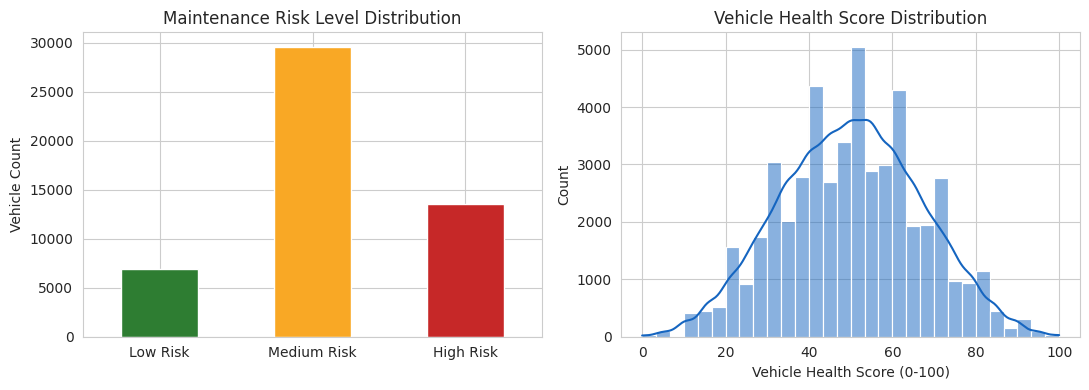

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df['Maintenance_Risk_Level'].value_counts().loc[['Low Risk', 'Medium Risk', 'High Risk']].plot(
    kind='bar', ax=axes[0], color=['#2e7d32', '#f9a825', '#c62828']
)
axes[0].set_title('Maintenance Risk Level Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Vehicle Count')
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(df['Vehicle_Health_Score'], bins=30, kde=True, ax=axes[1], color='#1565c0')
axes[1].set_title('Vehicle Health Score Distribution')
axes[1].set_xlabel('Vehicle Health Score (0-100)')

plt.tight_layout()
plt.show()


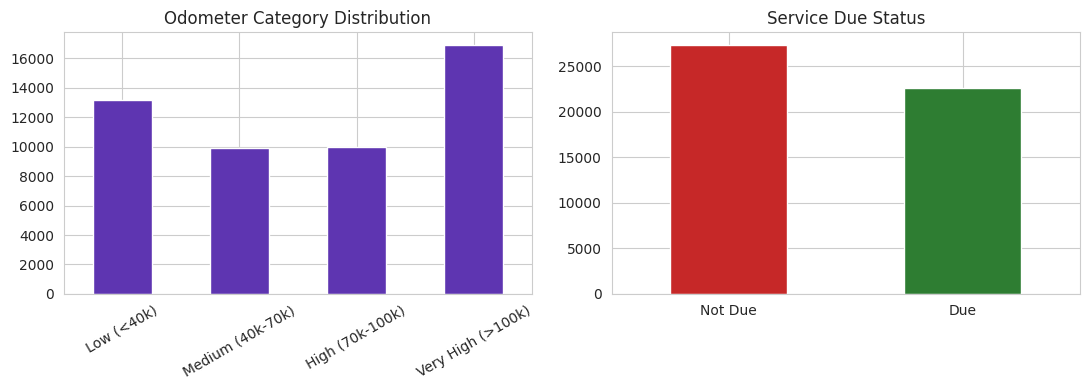

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df['Odometer_Category'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#5e35b1')
axes[0].set_title('Odometer Category Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

df['Service_Due_Status'].value_counts().plot(kind='bar', ax=axes[1], color=['#c62828', '#2e7d32'])
axes[1].set_title('Service Due Status')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 8. Export Final Dataset

Exporting the fully feature-engineered dataset as an SQL-ready CSV for downstream use by other AutoIntel AI
team members (modeling, dashboarding, and the diagnosis API).

In [23]:
OUTPUT_PATH = "vehicle_maintenance_feature_engineered.csv"

df.to_csv(OUTPUT_PATH, index=False)

print(f"Exported {df.shape[0]} rows x {df.shape[1]} columns to '{OUTPUT_PATH}'")
print("\nFinal column list:")
print(df.columns.tolist())


Exported 50000 rows x 33 columns to 'vehicle_maintenance_feature_engineered.csv'

Final column list:
['Vehicle_ID', 'vehicle_model', 'mileage', 'maintenance_history', 'reported_issues', 'vehicle_age', 'fuel_type', 'transmission_type', 'engine_size', 'odometer_reading', 'last_service_date', 'warranty_expiry_date', 'owner_type', 'insurance_premium', 'service_history', 'accident_history', 'fuel_efficiency', 'tire_condition', 'brake_condition', 'battery_status', 'need_maintenance', 'Months_Since_Last_Service', 'Warranty_Status', 'Warranty_Remaining_Months', 'Odometer_Category', 'Fuel_Efficiency_Rating', 'Annual_Mileage', 'Vehicle_Usage_Category', 'Service_Due_Status', 'Component_Wear_Score', 'Issue_Rate', 'Vehicle_Health_Score', 'Maintenance_Risk_Level']


### 9. Summary and Observations

**Work completed in this notebook**
- Validated the Week 1 cleaned Vehicle Maintenance dataset (structural + domain checks) without repeating
  any cleaning steps.
- Engineered **12 new features** across four themes: service recency & warranty, usage & mileage,
  component/fuel condition ratings, and a composite health/risk score.
- Added two features beyond the original brief (`Annual_Mileage`, `Issue_Rate`, `Component_Wear_Score`)
  where the raw columns alone were not sufficiently normalized for fair comparison across vehicles.
- Validated every new feature for missing values and logical range, and cross-checked the composite health
  score against the existing `need_maintenance` label purely as a sanity check (not as an input).
- Exported an SQL-ready `vehicle_maintenance_feature_engineered.csv` (50,000 rows × 33 columns).

**Key observations**
- `Vehicle_Health_Score` and `Maintenance_Risk_Level` show strong directional agreement with
  `need_maintenance`, despite not using that column as an input — a good early signal that the diagnosis
  model downstream will have useful features to work with.
- `Warranty_Status` is constant (`Active`) at the current snapshot date because the dataset's warranty
  window starts shortly after its service-date window ends; `Warranty_Remaining_Months` still preserves
  the full underlying variation and should be preferred over `Warranty_Status` for modeling until later
  snapshots are available.
- `fuel_efficiency` does not vary meaningfully by `fuel_type` or `vehicle_model` in this dataset, so a
  single fleet-wide rating was used instead of a per-group one.

**Handoff to other AutoIntel AI members**
`vehicle_maintenance_feature_engineered.csv` is ready for Member 2 (Modeling) to consume directly, and for
Member 3 (Dashboarding) to use `Maintenance_Risk_Level` and `Vehicle_Health_Score` as headline metrics.
